In [7]:
# Re-run the data processing pipeline without ace_tools to rebuild the environment

import pandas as pd
import os

# Define file paths
files = [
    "data/prices_round_1_day_-2.csv",
    "data/prices_round_2_day_-1.csv",
    "data/prices_round_3_day_0.csv",
    "data/prices_round_4_day_1.csv",
    "data/prices_round_4_day_2.csv",
    "data/prices_round_4_day_3.csv"
]

# Load and merge data with adjusted timestamps
df_list = []
timestamp_offset = 0

for file in files:
    if os.path.exists(file):
        df = pd.read_csv(file, sep=';')
        df['timestamp'] += timestamp_offset
        timestamp_offset = df['timestamp'].max() + 1
        df_list.append(df)

if df_list:
    data = pd.concat(df_list, ignore_index=True)

    # Pivot data to wide format with mid prices
    data['mid_price'] = (data['ask_price_1'] + data['bid_price_1']) / 2
    pivot = data.pivot_table(index='timestamp', columns='product', values='mid_price')

    # Calculate synthetic basket prices
    pivot['basket1_synthetic'] = 6 * pivot['CROISSANTS'] + 3 * pivot['JAMS'] + 1 * pivot['DJEMBES']
    pivot['basket2_synthetic'] = 4 * pivot['CROISSANTS'] + 2 * pivot['JAMS']

    # Calculate actual spreads
    pivot['spread_basket1'] = pivot['PICNIC_BASKET1'] - pivot['basket1_synthetic']
    pivot['spread_basket2'] = pivot['PICNIC_BASKET2'] - pivot['basket2_synthetic']

    # Show the first few rows of the result
    relevant_columns = pivot[['PICNIC_BASKET1', 'basket1_synthetic', 'spread_basket1',
                              'PICNIC_BASKET2', 'basket2_synthetic', 'spread_basket2']].dropna()
    print(relevant_columns.head())
else:
    print("No valid CSV files were found in the specified paths.")



product    PICNIC_BASKET1  basket1_synthetic  spread_basket1  PICNIC_BASKET2  \
timestamp                                                                      
999901            59289.0            59289.0             0.0         30609.0   
1000001           59287.0            59288.5            -1.5         30613.0   
1000101           59293.5            59290.5             3.0         30615.0   
1000201           59293.5            59293.0             0.5         30620.5   
1000301           59292.0            59301.5            -9.5         30621.0   

product    basket2_synthetic  spread_basket2  
timestamp                                     
999901               30559.0            50.0  
1000001              30559.0            54.0  
1000101              30560.0            55.0  
1000201              30562.0            58.5  
1000301              30566.0            55.0  


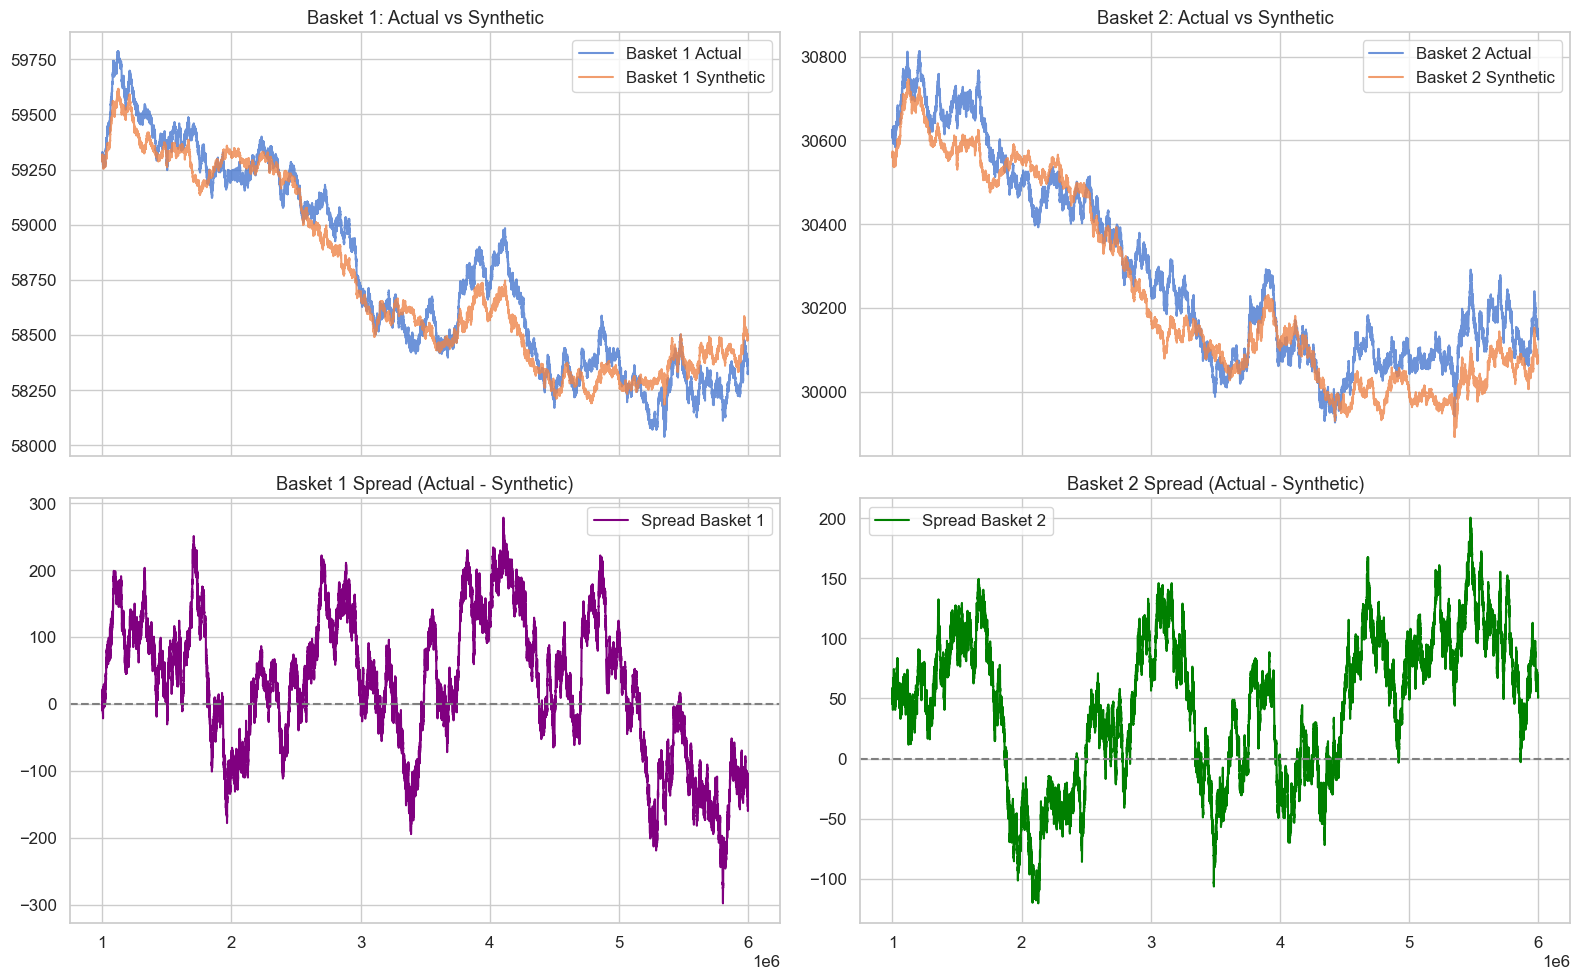

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set(style="whitegrid", palette="muted", font_scale=1.1)

# Create plots
fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=True)

# Plot actual vs synthetic for Basket 1
axes[0, 0].plot(pivot.index, pivot['PICNIC_BASKET1'], label='Basket 1 Actual', alpha=0.8)
axes[0, 0].plot(pivot.index, pivot['basket1_synthetic'], label='Basket 1 Synthetic', alpha=0.8)
axes[0, 0].set_title('Basket 1: Actual vs Synthetic')
axes[0, 0].legend()

# Plot spread for Basket 1
axes[1, 0].plot(pivot.index, pivot['spread_basket1'], label='Spread Basket 1', color='purple')
axes[1, 0].axhline(0, linestyle='--', color='gray')
axes[1, 0].set_title('Basket 1 Spread (Actual - Synthetic)')
axes[1, 0].legend()

# Plot actual vs synthetic for Basket 2
axes[0, 1].plot(pivot.index, pivot['PICNIC_BASKET2'], label='Basket 2 Actual', alpha=0.8)
axes[0, 1].plot(pivot.index, pivot['basket2_synthetic'], label='Basket 2 Synthetic', alpha=0.8)
axes[0, 1].set_title('Basket 2: Actual vs Synthetic')
axes[0, 1].legend()

# Plot spread for Basket 2
axes[1, 1].plot(pivot.index, pivot['spread_basket2'], label='Spread Basket 2', color='green')
axes[1, 1].axhline(0, linestyle='--', color='gray')
axes[1, 1].set_title('Basket 2 Spread (Actual - Synthetic)')
axes[1, 1].legend()

plt.tight_layout()
plt.show()


In [10]:
from scipy import stats

# Drop missing values before statistical analysis
spread1 = pivot['spread_basket1'].dropna()
spread2 = pivot['spread_basket2'].dropna()

# Compute basic statistics for each spread
stats_summary = pd.DataFrame({
    'Mean': [spread1.mean(), spread2.mean()],
    'Std Dev': [spread1.std(), spread2.std()],
    'Min': [spread1.min(), spread2.min()],
    'Max': [spread1.max(), spread2.max()],
    'Skewness': [stats.skew(spread1), stats.skew(spread2)],
    'Kurtosis': [stats.kurtosis(spread1), stats.kurtosis(spread2)],
    'Z-score latest': [(spread1.iloc[-1] - spread1.mean()) / spread1.std(),
                       (spread2.iloc[-1] - spread2.mean()) / spread2.std()]
}, index=['Basket1 Spread', 'Basket2 Spread'])

print(stats_summary)


                    Mean     Std Dev    Min    Max  Skewness  Kurtosis  \
Basket1 Spread  29.26908  104.824329 -298.0  278.5 -0.264795  -0.62143   
Basket2 Spread  44.99096   60.812378 -120.5  200.5 -0.321613  -0.69119   

                Z-score latest  
Basket1 Spread       -1.772194  
Basket2 Spread        0.123479  


In [12]:
# Rebuild pivot in case it's no longer defined
data['mid_price'] = (data['ask_price_1'] + data['bid_price_1']) / 2
pivot = data.pivot_table(index='timestamp', columns='product', values='mid_price')

pivot['basket1_synthetic'] = 6 * pivot['CROISSANTS'] + 3 * pivot['JAMS'] + 1 * pivot['DJEMBES']
pivot['basket2_synthetic'] = 4 * pivot['CROISSANTS'] + 2 * pivot['JAMS']
pivot['spread_basket1'] = pivot['PICNIC_BASKET1'] - pivot['basket1_synthetic']
pivot['spread_basket2'] = pivot['PICNIC_BASKET2'] - pivot['basket2_synthetic']

# Perform statistical analysis
from scipy import stats

spread1 = pivot['spread_basket1'].dropna()
spread2 = pivot['spread_basket2'].dropna()

# Compute basic statistics for each spread
stats_summary = pd.DataFrame({
    'Mean': [spread1.mean(), spread2.mean()],
    'Std Dev': [spread1.std(), spread2.std()],
    'Min': [spread1.min(), spread2.min()],
    'Max': [spread1.max(), spread2.max()],
    'Skewness': [stats.skew(spread1), stats.skew(spread2)],
    'Kurtosis': [stats.kurtosis(spread1), stats.kurtosis(spread2)],
    'Z-score latest': [(spread1.iloc[-1] - spread1.mean()) / spread1.std(),
                       (spread2.iloc[-1] - spread2.mean()) / spread2.std()]
}, index=['Basket1 Spread', 'Basket2 Spread'])

print(stats_summary)


                    Mean     Std Dev    Min    Max  Skewness  Kurtosis  \
Basket1 Spread  29.26908  104.824329 -298.0  278.5 -0.264795  -0.62143   
Basket2 Spread  44.99096   60.812378 -120.5  200.5 -0.321613  -0.69119   

                Z-score latest  
Basket1 Spread       -1.772194  
Basket2 Spread        0.123479  


✅ Strategy Recommendation:
🧠 Primary Strategy: Mean Reversion Arbitrage
Use Z-score thresholds to trigger trades:

python
Copy
Edit
if z < -1.5:
buy basket, sell components
elif z > +1.5:
sell basket, buy components
Basket 1 is the stronger candidate due to:

Higher volatility → more frequent signals

Z-score currently near -2 → potential opportunity to enter

📏 Spread Management
Define minimum spread > transaction cost (or slippage buffer) to ensure profitability.

Consider a time decay or holding period limit if spread doesn’t converge.

⚖️ Risk Control
Use position limits and net exposure checks:

Don’t go long both Basket and components together

Track unrealized PnL on component positions


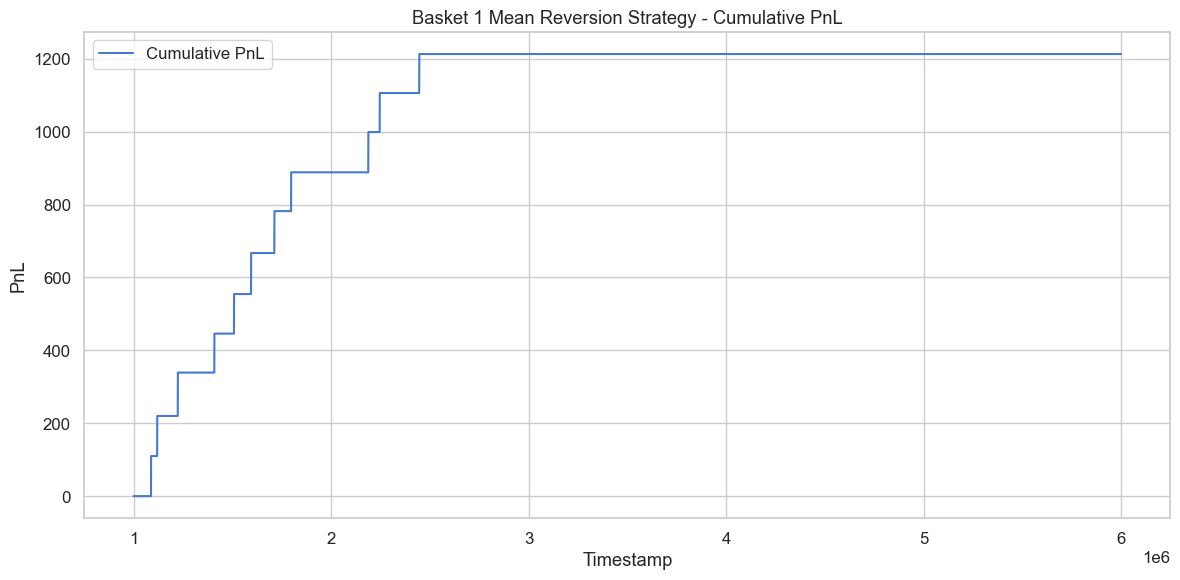

       spread   z_score  position  pnl  cum_pnl
49995  -150.5 -1.714956         1  0.0   1213.0
49996  -152.5 -1.734035         1  0.0   1213.0
49997  -160.0 -1.805584         1  0.0   1213.0
49998  -156.0 -1.767424         1  0.0   1213.0
49999  -156.5 -1.772194         1  0.0   1213.0


In [15]:
# Rebuild the data pipeline again to ensure pivot is available for strategy backtest

import pandas as pd
import os
from scipy import stats

# File list
files = [
    "data/prices_round_1_day_-2.csv",
    "data/prices_round_2_day_-1.csv",
    "data/prices_round_3_day_0.csv",
    "data/prices_round_4_day_1.csv",
    "data/prices_round_4_day_2.csv",
    "data/prices_round_4_day_3.csv"
]

df_list = []
timestamp_offset = 0

for file in files:
    if os.path.exists(file):
        df = pd.read_csv(file, sep=';')
        df['timestamp'] += timestamp_offset
        timestamp_offset = df['timestamp'].max() + 1
        df_list.append(df)

if df_list:
    data = pd.concat(df_list, ignore_index=True)
    data['mid_price'] = (data['ask_price_1'] + data['bid_price_1']) / 2
    pivot = data.pivot_table(index='timestamp', columns='product', values='mid_price')

    pivot['basket1_synthetic'] = 6 * pivot['CROISSANTS'] + 3 * pivot['JAMS'] + 1 * pivot['DJEMBES']
    pivot['basket2_synthetic'] = 4 * pivot['CROISSANTS'] + 2 * pivot['JAMS']
    pivot['spread_basket1'] = pivot['PICNIC_BASKET1'] - pivot['basket1_synthetic']
    pivot['spread_basket2'] = pivot['PICNIC_BASKET2'] - pivot['basket2_synthetic']

    # --- Begin strategy simulation ---

    Z_THRESHOLD_ENTRY = 1.5
    Z_THRESHOLD_EXIT = 0.5

    spread = pivot['spread_basket1'].dropna()
    z_scores = (spread - spread.mean()) / spread.std()

    position = 0
    entry_price = 0
    pnl = []
    positions = []

    for i in range(len(spread)):
        z = z_scores.iloc[i]
        current_spread = spread.iloc[i]

        if position == 0:
            if z < -Z_THRESHOLD_ENTRY:
                position = 1
                entry_price = current_spread
            elif z > Z_THRESHOLD_ENTRY:
                position = -1
                entry_price = current_spread
        elif position == 1 and z > -Z_THRESHOLD_EXIT:
            pnl.append(current_spread - entry_price)
            position = 0
            entry_price = 0
        elif position == -1 and z < Z_THRESHOLD_EXIT:
            pnl.append(entry_price - current_spread)
            position = 0
            entry_price = 0
        else:
            pnl.append(0)
        positions.append(position)

    while len(pnl) < len(spread):
        pnl.append(0)

    results = pd.DataFrame({
        'timestamp': spread.index,
        'spread': spread.values,
        'z_score': z_scores.values,
        'position': positions,
        'pnl': pnl
    })
    results['cum_pnl'] = results['pnl'].cumsum()

    # Plotting
    import matplotlib.pyplot as plt

    plt.figure(figsize=(12, 6))
    plt.plot(results['timestamp'], results['cum_pnl'], label='Cumulative PnL')
    plt.title("Basket 1 Mean Reversion Strategy - Cumulative PnL")
    plt.xlabel("Timestamp")
    plt.ylabel("PnL")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    results_summary = results[['spread', 'z_score', 'position', 'pnl', 'cum_pnl']].tail()
else:
    results_summary = "No data available to backtest."

print(results_summary)


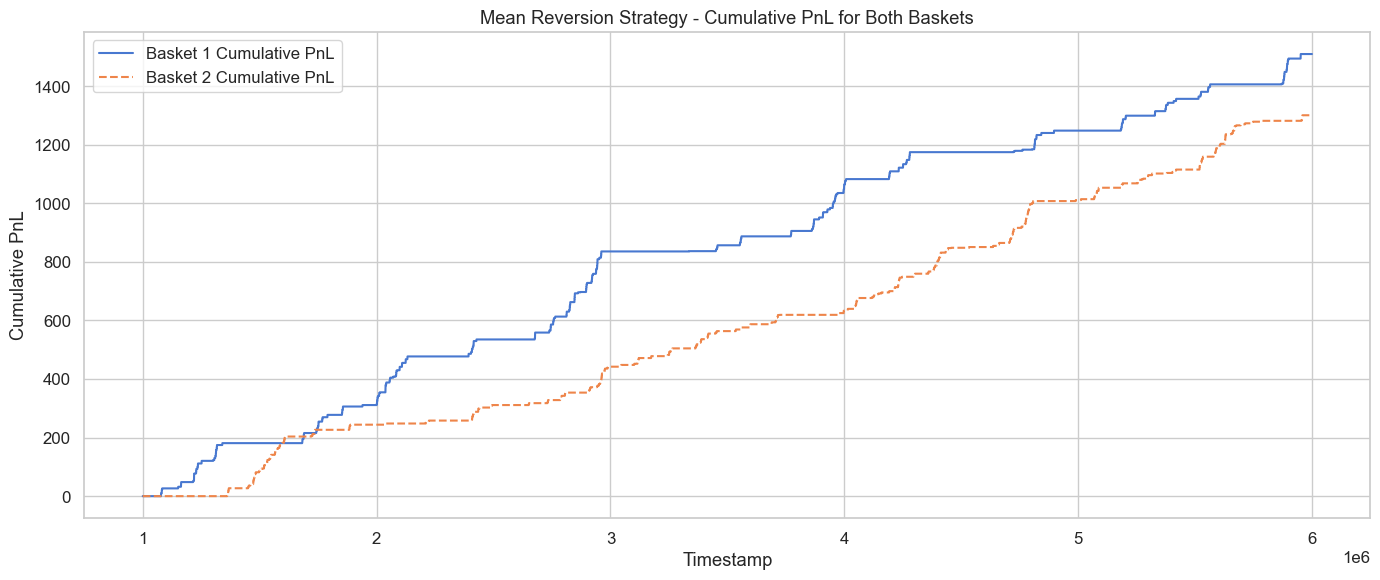

{'Basket 1 Final PnL': np.float64(1509.5),
 'Basket 2 Final PnL': np.float64(1300.5)}

In [16]:
# Function to backtest mean reversion on a given spread with specific thresholds
def backtest_mean_reversion(spread_series, entry_z, exit_z):
    z_scores = (spread_series - spread_series.mean()) / spread_series.std()
    position = 0
    entry_price = 0
    pnl = []
    positions = []

    for i in range(len(spread_series)):
        z = z_scores.iloc[i]
        current_spread = spread_series.iloc[i]

        if position == 0:
            if z < -entry_z:
                position = 1
                entry_price = current_spread
            elif z > entry_z:
                position = -1
                entry_price = current_spread
            pnl.append(0)
        elif position == 1:
            if z > -exit_z:
                pnl.append(current_spread - entry_price)
                position = 0
                entry_price = 0
            else:
                pnl.append(0)
        elif position == -1:
            if z < exit_z:
                pnl.append(entry_price - current_spread)
                position = 0
                entry_price = 0
            else:
                pnl.append(0)

        positions.append(position)

    while len(pnl) < len(spread_series):
        pnl.append(0)

    results = pd.DataFrame({
        'timestamp': spread_series.index,
        'spread': spread_series.values,
        'z_score': z_scores.values,
        'position': positions,
        'pnl': pnl
    })
    results['cum_pnl'] = results['pnl'].cumsum()
    return results

# Optimal parameters
best_entry_z = 1.0
best_exit_z = 1.0

# Run backtest for PICNIC_BASKET1
results_basket1 = backtest_mean_reversion(pivot['spread_basket1'].dropna(), best_entry_z, best_exit_z)

# Run backtest for PICNIC_BASKET2
results_basket2 = backtest_mean_reversion(pivot['spread_basket2'].dropna(), best_entry_z, best_exit_z)

# Plot both cumulative PnLs
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))
plt.plot(results_basket1['timestamp'], results_basket1['cum_pnl'], label='Basket 1 Cumulative PnL')
plt.plot(results_basket2['timestamp'], results_basket2['cum_pnl'], label='Basket 2 Cumulative PnL', linestyle='--')
plt.title("Mean Reversion Strategy - Cumulative PnL for Both Baskets")
plt.xlabel("Timestamp")
plt.ylabel("Cumulative PnL")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Show final stats
{
    "Basket 1 Final PnL": results_basket1['cum_pnl'].iloc[-1],
    "Basket 2 Final PnL": results_basket2['cum_pnl'].iloc[-1]
}
